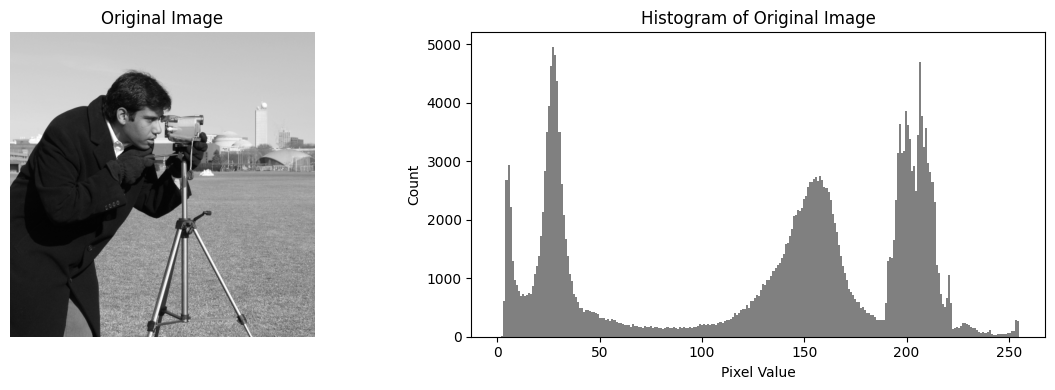

Image shape: (512, 512)
Pixel value range: 0.0 to 255.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

image = data.camera().astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].hist(image.ravel(), bins=256, color='gray')
axes[1].set_title('Histogram of Original Image')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Pixel value range: {image.min()} to {image.max()}")

In [9]:
def add_gaussian_noise(image, mean=0, std=1):
    print(f"--- Gaussian Noise | mean={mean}, std={std} ---")
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


def add_rayleigh_noise(image, scale=1):
    print(f"--- Rayleigh Noise | scale={scale} ---")
    rayleigh_noise = np.random.rayleigh(scale, image.shape)
    noisy_image = image + rayleigh_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


def add_exponential_noise(image, scale=1):
    print(f"--- Exponential Noise | scale={scale} ---")
    exponential_noise = np.random.exponential(scale, image.shape)
    noisy_image = image + exponential_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    print(f"--- Salt & Pepper Noise | salt={salt_prob}, pepper={pepper_prob} ---")
    noisy_image = image.copy()

    # Salt = white pixels
    num_salt = int(np.ceil(salt_prob * image.size))
    salt_rows = np.random.randint(0, image.shape[0], num_salt)
    salt_cols = np.random.randint(0, image.shape[1], num_salt)
    noisy_image[salt_rows, salt_cols] = 255

    # Pepper = black pixels
    num_pepper = int(np.ceil(pepper_prob * image.size))
    pepper_rows = np.random.randint(0, image.shape[0], num_pepper)
    pepper_cols = np.random.randint(0, image.shape[1], num_pepper)
    noisy_image[pepper_rows, pepper_cols] = 0

    return noisy_image


def add_uniform_noise(image, low=0, high=10):
    print(f"--- Uniform Noise | low={low}, high={high} ---")
    uniform_noise = np.random.uniform(low, high, image.shape)
    noisy_image = image + uniform_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image


print("All noise functions defined successfully!")

All noise functions defined successfully!


--- Gaussian Noise | mean=0, std=25 ---
--- Rayleigh Noise | scale=20 ---
--- Exponential Noise | scale=20 ---
--- Salt & Pepper Noise | salt=0.05, pepper=0.05 ---
--- Uniform Noise | low=-30, high=30 ---


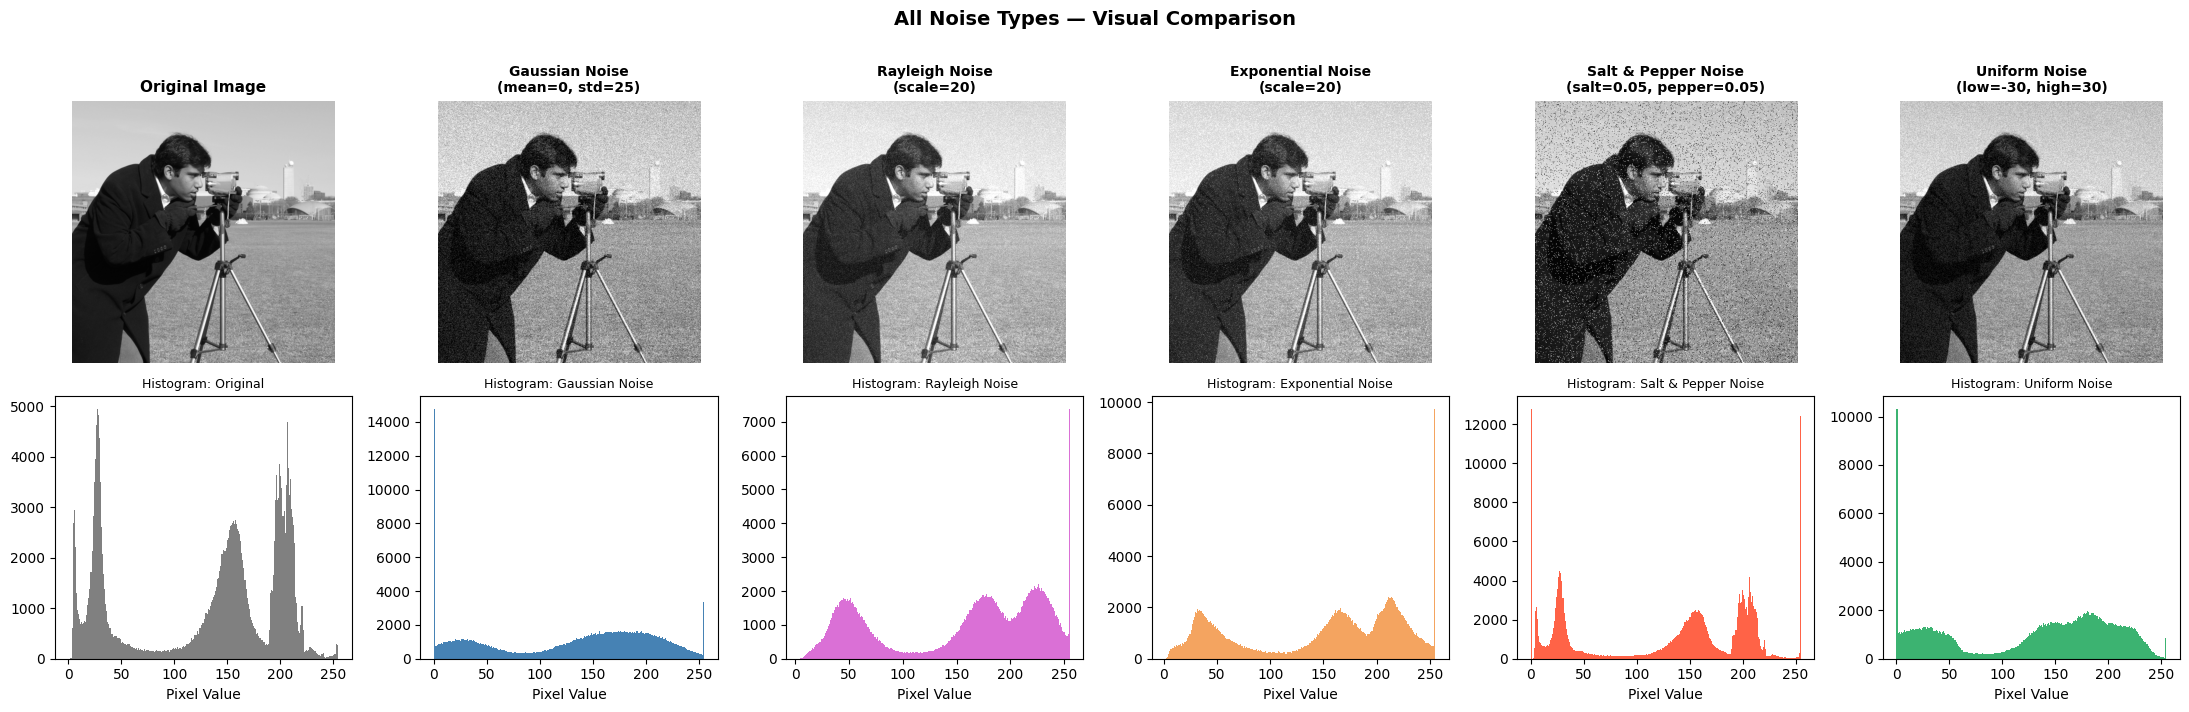

In [10]:

noise_demos = [
    ("Gaussian Noise\n(mean=0, std=25)",      add_gaussian_noise(image, mean=0, std=25)),
    ("Rayleigh Noise\n(scale=20)",             add_rayleigh_noise(image, scale=20)),
    ("Exponential Noise\n(scale=20)",          add_exponential_noise(image, scale=20)),
    ("Salt & Pepper Noise\n(salt=0.05, pepper=0.05)", add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)),
    ("Uniform Noise\n(low=-30, high=30)",      add_uniform_noise(image, low=-30, high=30)),
]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))


axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i, (title, noisy) in enumerate(noise_demos):
    axes[0, i+1].imshow(noisy, cmap='gray', vmin=0, vmax=255)
    axes[0, i+1].set_title(title, fontsize=10, fontweight='bold')
    axes[0, i+1].axis('off')


axes[1, 0].hist(image.ravel(), bins=256, color='gray')
axes[1, 0].set_title('Histogram: Original', fontsize=9)
axes[1, 0].set_xlabel('Pixel Value')

colors = ['steelblue', 'orchid', 'sandybrown', 'tomato', 'mediumseagreen']
for i, ((title, noisy), color) in enumerate(zip(noise_demos, colors)):
    axes[1, i+1].hist(noisy.ravel(), bins=256, color=color)
    axes[1, i+1].set_title(f'Histogram: {title.split(chr(10))[0]}', fontsize=9)
    axes[1, i+1].set_xlabel('Pixel Value')

plt.suptitle('All Noise Types — Visual Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import copy

# ============================================================
# FILTER ENGINE — Generic sliding window
# ============================================================

def apply_filter(image_input, filt_size, operation):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    result = copy.deepcopy(image_input)
    row, col = image_input.shape
    for i in range(row):
        for j in range(col):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            result[i, j] = operation(patch)
    return np.clip(result, 0, 255)


# ============================================================
# MEAN-TYPE FILTERS
# ============================================================

def box_filter(image, filt_size):
    """Arithmetic Mean — averages all pixels in window."""
    n = filt_size * filt_size
    box = np.ones((filt_size, filt_size)) / n
    return apply_filter(image, filt_size, lambda patch: np.sum(box * patch))

def geometric_mean_filter(image, filt_size):
    """Geometric Mean — Nth root of product; preserves detail better than mean."""
    n = filt_size * filt_size
    def op(patch):
        return np.exp(np.sum(np.log(patch + 1e-10)) / n)
    return apply_filter(image, filt_size, op)

def harmonic_mean_filter(image, filt_size):
    """Harmonic Mean — good for salt (white) noise."""
    n = filt_size * filt_size
    return apply_filter(image, filt_size,
                        lambda patch: n / np.sum(1.0 / (patch + 1e-10)))

def contraharmonic_mean_filter(image, filt_size, Q):
    """Contraharmonic — Q>0 removes pepper, Q<0 removes salt."""
    def op(patch):
        p = patch + 1e-10
        return np.sum(p ** (Q + 1)) / (np.sum(p ** Q) + 1e-10)
    return apply_filter(image, filt_size, op)


# ============================================================
# ORDER STATISTIC FILTERS
# ============================================================

def median_filter(image, filt_size):
    """Median — best for Salt & Pepper noise."""
    return apply_filter(image, filt_size, lambda patch: np.median(patch))

def max_filter(image, filt_size):
    """Max — removes pepper (black dots), brightens image."""
    return apply_filter(image, filt_size, lambda patch: np.max(patch))

def min_filter(image, filt_size):
    """Min — removes salt (white dots), darkens image."""
    return apply_filter(image, filt_size, lambda patch: np.min(patch))

def midpoint_filter(image, filt_size):
    """Midpoint — average of max and min; good for uniform/Gaussian noise."""
    return apply_filter(image, filt_size,
                        lambda patch: (np.max(patch) + np.min(patch)) / 2)

def alpha_trimmed_mean_filter(image, filt_size, d):
    """Alpha-Trimmed — removes d/2 extremes from each end before averaging."""
    n = filt_size * filt_size
    d_half = d // 2
    def op(patch):
        s = np.sort(patch.ravel())
        return np.mean(s[d_half: n - d_half])
    return apply_filter(image, filt_size, op)


print("All filter functions defined!")
print("  Mean-type  : box_filter, geometric_mean_filter, harmonic_mean_filter, contraharmonic_mean_filter")
print("  Order stat : median_filter, max_filter, min_filter, midpoint_filter, alpha_trimmed_mean_filter")

In [ ]:
import copy
from skimage.transform import resize

# ============================================================
# FILTER DEFINITIONS
# ============================================================

def apply_filter(image_input, filt_size, operation):
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    result = copy.deepcopy(image_input)
    row, col = image_input.shape
    for i in range(row):
        for j in range(col):
            patch = image_padded[i:i + filt_size, j:j + filt_size]
            result[i, j] = operation(patch)
    return np.clip(result, 0, 255)

def box_filter(image, filt_size):
    n = filt_size * filt_size
    return apply_filter(image, filt_size, lambda patch: np.sum(patch) / n)

def geometric_mean_filter(image, filt_size):
    n = filt_size * filt_size
    return apply_filter(image, filt_size,
                        lambda patch: np.exp(np.sum(np.log(patch + 1e-10)) / n))

def harmonic_mean_filter(image, filt_size):
    n = filt_size * filt_size
    return apply_filter(image, filt_size,
                        lambda patch: n / np.sum(1.0 / (patch + 1e-10)))

def contraharmonic_mean_filter(image, filt_size, Q):
    def op(patch):
        p = patch + 1e-10
        return np.sum(p ** (Q + 1)) / (np.sum(p ** Q) + 1e-10)
    return apply_filter(image, filt_size, op)

def median_filter(image, filt_size):
    return apply_filter(image, filt_size, lambda patch: np.median(patch))

def max_filter(image, filt_size):
    return apply_filter(image, filt_size, lambda patch: np.max(patch))

def min_filter(image, filt_size):
    return apply_filter(image, filt_size, lambda patch: np.min(patch))

def midpoint_filter(image, filt_size):
    return apply_filter(image, filt_size,
                        lambda patch: (np.max(patch) + np.min(patch)) / 2)

def alpha_trimmed_mean_filter(image, filt_size, d):
    n = filt_size * filt_size
    d_half = d // 2
    def op(patch):
        s = np.sort(patch.ravel())
        return np.mean(s[d_half: n - d_half])
    return apply_filter(image, filt_size, op)

print("Filter functions defined!")

# ============================================================
# NOISY IMAGE VARIABLES
# ============================================================

img = resize(image, (128, 128), anti_aliasing=True) * 255
img = img.astype(np.float64)

noisy_gaussian = add_gaussian_noise(img,  mean=0,  std=25)
noisy_rayleigh = add_rayleigh_noise(img,  scale=20)
noisy_exp      = add_exponential_noise(img, scale=20)
noisy_sp       = add_salt_pepper_noise(img, salt_prob=0.05, pepper_prob=0.05)
noisy_uniform  = add_uniform_noise(img,   low=-30, high=30)

print("\nNoisy variables: noisy_gaussian, noisy_rayleigh, noisy_exp, noisy_sp, noisy_uniform")

# ============================================================
# APPLY FILTERS
# ============================================================

print("\nApplying filters — please wait (~30 sec)...")

filt_gauss_mean     = box_filter(noisy_gaussian, 3)
filt_gauss_geo      = geometric_mean_filter(noisy_gaussian, 3)
filt_gauss_midpoint = midpoint_filter(noisy_gaussian, 3)

filt_rayleigh_mean     = box_filter(noisy_rayleigh, 3)
filt_rayleigh_geo      = geometric_mean_filter(noisy_rayleigh, 3)
filt_rayleigh_midpoint = midpoint_filter(noisy_rayleigh, 3)

filt_exp_geo      = geometric_mean_filter(noisy_exp, 3)
filt_exp_mean     = box_filter(noisy_exp, 3)
filt_exp_midpoint = midpoint_filter(noisy_exp, 3)

filt_sp_median = median_filter(noisy_sp, 3)
filt_sp_alpha  = alpha_trimmed_mean_filter(noisy_sp, 3, d=4)
filt_sp_mean   = box_filter(noisy_sp, 3)

filt_uniform_mean     = box_filter(noisy_uniform, 3)
filt_uniform_midpoint = midpoint_filter(noisy_uniform, 3)

print("Done! Scroll down to see comparisons.")

In [ ]:
# FILTER RECOVERY — Gaussian Noise
# Mean filter works best: averages out random +/- values

imgs_gauss   = [img, noisy_gaussian, filt_gauss_mean, filt_gauss_geo, filt_gauss_midpoint]
titles_gauss = ['Original', 'Gaussian Noisy\n(mean=0, std=25)',
                'Mean Filter 3x3\n★ BEST', 'Geometric Mean 3x3\n(good)', 'Midpoint 3x3\n(decent)']
borders_gauss = ['black', 'steelblue', 'limegreen', 'gold', 'orange']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, im, title, bc in zip(axes, imgs_gauss, titles_gauss, borders_gauss):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(bc); sp.set_linewidth(3)
plt.suptitle('Gaussian Noise  ->  Best Fix: Mean (Box) Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Best filter for Gaussian noise: Mean (Box) Filter')

In [ ]:
# FILTER RECOVERY — Rayleigh Noise
# Mean filter works best: pulls down the always-positive brightness bias

imgs_ray   = [img, noisy_rayleigh, filt_rayleigh_mean, filt_rayleigh_geo, filt_rayleigh_midpoint]
titles_ray = ['Original', 'Rayleigh Noisy\n(scale=20)',
              'Mean Filter 3x3\n★ BEST', 'Geometric Mean 3x3\n(good)', 'Midpoint 3x3\n(decent)']
borders_ray = ['black', 'orchid', 'limegreen', 'gold', 'orange']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, im, title, bc in zip(axes, imgs_ray, titles_ray, borders_ray):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(bc); sp.set_linewidth(3)
plt.suptitle('Rayleigh Noise  ->  Best Fix: Mean Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Best filter for Rayleigh noise: Mean (Box) Filter')

In [ ]:
# FILTER RECOVERY — Exponential Noise
# Geometric mean works best: handles the skewed positive-only distribution

imgs_exp   = [img, noisy_exp, filt_exp_geo, filt_exp_mean, filt_exp_midpoint]
titles_exp = ['Original', 'Exponential Noisy\n(scale=20)',
              'Geometric Mean 3x3\n★ BEST', 'Mean Filter 3x3\n(good)', 'Midpoint 3x3\n(decent)']
borders_exp = ['black', 'sandybrown', 'limegreen', 'gold', 'orange']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, im, title, bc in zip(axes, imgs_exp, titles_exp, borders_exp):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(bc); sp.set_linewidth(3)
plt.suptitle('Exponential Noise  ->  Best Fix: Geometric Mean Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Best filter for Exponential noise: Geometric Mean Filter')

In [ ]:
# FILTER RECOVERY — Salt & Pepper Noise
# Median filter is the gold standard: picks middle value, ignores extreme dots

imgs_sp   = [img, noisy_sp, filt_sp_median, filt_sp_alpha, filt_sp_mean]
titles_sp = ['Original', 'S&P Noisy\n(5%+5%)',
             'Median Filter 3x3\n★ BEST', 'Alpha-Trimmed d=4\n(decent)', 'Mean 3x3\n(blurs dots)']
borders_sp = ['black', 'tomato', 'limegreen', 'gold', 'salmon']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, im, title, bc in zip(axes, imgs_sp, titles_sp, borders_sp):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(bc); sp.set_linewidth(3)
plt.suptitle('Salt & Pepper Noise  ->  Best Fix: Median Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Best filter for Salt & Pepper noise: Median Filter')

In [ ]:
# FILTER RECOVERY — Uniform Noise
# Mean and Midpoint both work well: uniform noise averages out easily

imgs_uni   = [img, noisy_uniform, filt_uniform_mean, filt_uniform_midpoint]
titles_uni = ['Original', 'Uniform Noisy\n(low=-30, high=30)',
              'Mean Filter 3x3\n★ BEST', 'Midpoint 3x3\n(good)']
borders_uni = ['black', 'mediumseagreen', 'limegreen', 'gold']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, im, title, bc in zip(axes, imgs_uni, titles_uni, borders_uni):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(bc); sp.set_linewidth(3)
plt.suptitle('Uniform Noise  ->  Best Fix: Mean Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Best filter for Uniform noise: Mean (Box) Filter')